# Nucleus Detection

Click to open in: \[[GitHub](https://github.com/TissueImageAnalytics/tiatoolbox/blob/develop/examples/nucleus-detection.ipynb)\]\[[Colab](https://colab.research.google.com/github/TissueImageAnalytics/tiatoolbox/blob/develop/examples/nucleus-detection.ipynb)\]



## About this notebook

This jupyter notebook can be run on any computer with a standard browser and no prior installation of any programming language is required. It can run remotely over the Internet, free of charge, thanks to Google Colaboratory. To connect with Colab, click on one of the two blue checkboxes above. Check that "colab" appears in the address bar. You can right-click on "Open in Colab" and select "Open in new tab" if the left click does not work for you. Familiarize yourself with the drop-down menus near the top of the window. You can edit the notebook during the session, for example substituting your own image files for the image files used in this demo. Experiment by changing the parameters of functions. It is not possible for an ordinary user to permanently change this version of the notebook on GitHub or Colab, so you cannot inadvertently mess it up. Use the notebook's File Menu if you wish to save your own (changed) notebook.

To run the notebook on any platform, except for Colab, set up your Python environment, as explained in the
[README](https://github.com/TIA-Lab/tiatoolbox/blob/master/README.md#install-python-package) file.



## About this demo

Each WSI can contain up to million nuclei of various types, which can be further quantified systematically and used for predicting clinical outcomes. In order to perform nuclei quantification for downstream analysis within computational pathology, nucleus detectiion and classification must be carried out as an initial step. However, this is challenging because nuclei display a high level of heterogeneity and there is significant inter- and intra-instance variability in the shape, size and chromatin pattern between and within different cell types, disease types or even from one region to another within a single tissue sample.

> ![image](https://github.com/Jiaqi-Lv/KongNet_Inference_Main/raw/main/docs/example_zoomed_in.png)

In this example, we will demonstrate how you can use the TIAToolbox implementation of [KongNet](https://arxiv.org/abs/2510.23559) to tackle these challenges and solve the problem of nuclei detection and classification within histology images. KongNet is a a multi-headed deep learning architecture featuring a shared encoder and parallel, cell-type-specialised decoders. We validated KongNet in three Grand Challenges. It achieved first place on track 1 and second place on track 2 during the MONKEY Challenge. Its lightweight variant (KongNet-Det) secured first place in the 2025 MIDOG Challenge. KongNet ranked among the top three in the PUMA Challenge without further optimisation. Furthermore, KongNet established state-of-the-art performance on the publicly available PanNuke and CoNIC datasets.

In this example notebook, we are not going to explain how KongNet works (for more information we refer you to the [KongNet paper (currently under review)](https://arxiv.org/abs/2510.23559), but we will show how easily you can use the KongNet model to perform automatic detection and classification of nucleus instances. Mostly, we will be working with the [NucleusDetector](https://github.com/TissueImageAnalytics/tiatoolbox/blob/f852b069453f36f41bda0fb21dad4912b42d492a/tiatoolbox/models/engine/nucleus_detector.py#L140) which uses one of the pretrained [KongNet](https://github.com/TissueImageAnalytics/tiatoolbox/blob/35e9ad5119545ec9dbc86fe22e380f5b270cd258/tiatoolbox/models/architecture/kongnet.py#L464) models. We will also cover the [visualisation Interface](https://tia-toolbox.readthedocs.io/en/latest/visualization.html) embedded in TIAToolbox for overlaying the nuclei detection results on whole slide images.



## Setting up the environment

### TIAToolbox and dependencies installation

You can skip the following cell if 1) you are not using the Colab plaform or 2) you are using Colab and this is not your first run of the notebook in the current runtime session. If you nevertheless run the cell, you may get an error message, but no harm will be done. On Colab the cell installs `tiatoolbox`, and other prerequisite software. Harmless error messages should be ignored. Outside Colab , the notebook expects `tiatoolbox` to already be installed. (See the instructions in [README](https://github.com/TIA-Lab/tiatoolbox/blob/master/README.md#install-python-package).)



In [ ]:
%%bash
apt-get -y install libopenjp2-7-dev libopenjp2-tools openslide-tools libpixman-1-dev | tail -n 1
pip install git+https://github.com/TissueImageAnalytics/tiatoolbox.git@develop | tail -n 1
echo "Installation is done."

> **IMPORTANT**: If you are using Colab and you run the cell above for the first time, please note that you need to restart the runtime before proceeding through (menu) *"Runtime→Restart runtime"* . This is needed to load the latest versions of prerequisite packages installed with TIAToolbox. Doing so, you should be able to run all the remaining cells altogether (*"Runtime→Run after"* from the next cell) or one by one.



### Importing related libraries

We import some standard Python modules, and also the Python module `wsireader` (see [details](https://github.com/TIA-Lab/tiatoolbox/blob/master/tiatoolbox/wsicore/wsireader.py)) written by the TIA Centre team.



In [ ]:
"""Import modules required to run the Jupyter notebook."""
import sys

sys.path.append("..")  # to import from parent directory
# Clear logger to use tiatoolbox.logger
import logging
import warnings

if logging.getLogger().hasHandlers():
    logging.getLogger().handlers.clear()

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

from tiatoolbox import logger
from tiatoolbox.annotation.storage import SQLiteStore
from tiatoolbox.models.engine.nucleus_detector import NucleusDetector
from tiatoolbox.utils.misc import imread
import torch

# We need this function to visualize the nuclear predictions
from tiatoolbox.wsicore.wsireader import WSIReader

warnings.filterwarnings("ignore")
mpl.rcParams["figure.dpi"] = 300  # for high resolution figure in notebook
mpl.rcParams["figure.facecolor"] = "white"  # To make sure text is visible in dark mode
plt.rcParams.update({"font.size": 5})

### GPU or CPU runtime

Processes in this notebook can be accelerated by using a GPU. Therefore, whether you are running this notebook on your system or Colab, you need to check and specify appropriate [device](https://pytorch.org/docs/stable/tensor_attributes.html#torch.device) e.g., "cuda" or "cpu" whether you are using GPU or CPU. In Colab, you need to make sure that the runtime type is set to GPU in the *"Runtime→Change runtime type→Hardware accelerator"*. If you are *not* using GPU, consider changing the `device` flag to `cpu` value, otherwise, some errors will be raised when running the following cells.



In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"  # Choose appropriate device

### Removing leftovers from previous runs

The cell below removes some redundant directories if they exist—a previous run may have created them. This cell can be skipped if you are running this notebook for the first time.



In [ ]:
%%bash
rm -rf ./tmp/patch_results/
echo "deleting patch_results directory"

rm -rf ./tmp/wsi_results/
echo "deleting wsi_results directory"

### Downloading the required files

We download, over the internet, image files used for the purpose of this notebook. In particular, we download a whole slide image of cancerous breast tissue samples to show how the nucleus detection model works.

> In Colab, if you click the files icon (see below) in the vertical toolbar on the left hand side then you can see all the files that the code in this notebook can access. The data will appear here when it is downloaded.
>
> 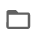



In [22]:
# These file name are used for the experimenets
tmp_dir = Path("./tmp/")

logger.info("Download has started. Please wait...")

CMC_patch_image_path = hf_hub_download(
    repo_id="TIACentre/TIAToolBox_Remote_Samples",
    subfolder="sample_imgs",
    filename="MIDOG_CMC_2191a7aa287ce1d5dbc0.png",
    repo_type="dataset",
    local_dir=tmp_dir,
)

CMC_wsi_path = hf_hub_download(
    repo_id="TIACentre/TIAToolBox_Remote_Samples",
    subfolder="sample_wsis",
    filename="MIDOG_CMC_2191a7aa287ce1d5dbc0.svs",
    repo_type="dataset",
    local_dir=tmp_dir,
)

PAS_wsi_path = hf_hub_download(
    repo_id="TIACentre/TIAToolBox_Remote_Samples",
    subfolder="sample_wsis",
    filename="D_P000019_PAS_CPG.tif",
    repo_type="dataset",
    local_dir=tmp_dir,
)

logger.info("Download is complete.")

sample_wsis/D_P000019_PAS_CPG.tif:   0%|          | 0.00/137M [00:00<?, ?B/s]

## Mitosis Detection using TIAToolbox's pretrained KongNet model

In this section, we will demonstrate the use of the pretrained KongNet models for Mitosis Detection. The model we demonstrate can detect mitotic figures in the image and output their coordinates.



### Inference on Patches

Similarly to the semantic segmentation engine, the nucleus detector works both on image patches and structured WSIs. First, we need to create an instance of the `NucleusDetector` class which controls the whole process of nucleus detection task and then use it to do prediction on the input image(s):



In [ ]:
detector = NucleusDetector(
    model="KongNet_Det_MIDOG_1",
    batch_size=1,
    num_workers=0,
    weights=None,
    device=device,
    verbose=True,
)

patch_output = detector.run(
    images=[CMC_patch_image_path],
    patch_mode=True,
    device=device,
    save_dir=tmp_dir / "patch_results",
    overwrite=True,
    output_type="annotationstore",
    auto_get_mask=False,
    memory_threshold=50,
    num_workers=0,
    batch_size=1,
    class_dict={0: "mitotic_figure"},
)

There we go! With only two lines of code, thousands of images can be processed automatically. There are various parameters associated with `NucleusDetector`. We explain these as we meet them while proceeding through the notebook. Here we explain only the ones mentioned above:

- `model`: specifies the name of the pretrained model included in the TIAToolbox (case sensitive). You can find a complete list of currently available pretrained models [here](<%5Bhttps://tia-toolbox.readthedocs.io/en/latest/usage.html?highlight=architecture#module-tiatoolbox.models.architecture%5D(https://tia-toolbox.readthedocs.io/en/latest/pretrained.html)>). In this example, we use the `"KongNet_Det_MIDOG_1"` pretrained model, which is `KongNet-Det` model trained on the [MIDOG2025 datasets](https://zenodo.org/records/15077361). There are also many other pretrained KongNet models, such as `"KongNet_CoNIC_1"`.

- `batch_size`: controls the batch size, or the number of input instances to the network in each iteration. If you use a GPU, be careful not to set the `batch_size` larger than the GPU memory limit would allow.

- `num_workers`: as the name suggests, this parameter controls the number of CPU cores (workers) that are responsible for the inference process, which consists of patch extraction, preprocessing, postprocessing etc.

- `weights`: Optional path to pretrained weights. If `"None"` and `"model"` is a string, default pretrained weights for that model will be used. If `"model"` is an `"nn.Module"`, weights are loaded only if provided.

- `device`: Device on which the model will run (e.g., `"cpu"`, `"cuda"`). Default is `"cpu"`.

- `verbose`: Whether to output logging information. Default is `True`.

After the `detector` has been instantiated with our desired pretrained model, one can call the `run` function to do inference on a list of input image patches (or WSIs). The `run` function automatically processes all the images on the input list and saves the results on the disk. The process usually comprises patch extraction if `patch_mode` is False (because the whole tile or WSI won't fit into limited GPU memory), preprocessing, model inference, post-processing and prediction assembly. Here are some important parameters required by the `predict` method properly:

- `images`: List of inputs to be processed. Can be a list of paths or numpy arrays.

- `patch_mode`: Whether to treat input as patches (`True`) or WSIs (`False`). Default is True.

- `device`: specify appropriate [device](https://pytorch.org/docs/stable/tensor_attributes.html#torch.device) e.g., "cuda", "cuda:0", "mps", "cpu" etc.

- `save_dir`: Path to the main folder in which prediction results for each input wil be stored, as well as any intermediate cache during WSI processing. We could set it to `None` when using `patch_mode=True`, in which case the results will simply be returned instead of saved to disk.

- `overwrite`: Whether to overwrite existing output files. Default is False.

- `output_type`: Desired output format: `"dict"`, `"zarr"`, or `"annotationstore"`. Default is `"dict"`. However, `"dict"` can only be used when `patch_model` is True, otherwise we should use either `"zarr"` or `"annotationstore"`.

- `auto_get_mask`: Whether to automatically generate tissue masks using `wsireader.tissue_mask()` during processing. We don't normally need it for patch mode as patches are small in size and normally contain only tissue region.

- `memory_threshold`: Memory usage threshold (in percentage) to trigger caching behavior. Default is 80.

- `batch_size`: controls the batch size, or the number of input instances to the network in each iteration. If you use a GPU, be careful not to set the `batch_size` larger than the GPU memory limit would allow. Can override this here.

- `num_workers`: as the name suggests, this parameter controls the number of CPU cores (workers) that are responsible for the inference process, which consists of patch extraction, preprocessing, postprocessing etc. Can override this here.

In `patch_output`, the `run` function returns a dictionary containing nucleus detection output.

Now that the prediction has finished, let's examine the predictions.



In [ ]:
patch_annotation_store_path = patch_output[0]

patch_annotation_store = SQLiteStore.open(patch_annotation_store_path)

x_coords = []
y_coords = []

for annotation in patch_annotation_store.values():
    x, y = annotation.geometry.centroid.coords[0]

    x_coords.append(x)
    y_coords.append(y)
    logger.info("%s, x: %.2f, y: %.2f", annotation.properties["type"], x, y)


patch_image = imread(CMC_patch_image_path)


fig, axes = plt.subplots(1, 1, figsize=(3, 3))
axes.imshow(patch_image)
axes.axis("off")

axes.scatter(y_coords, x_coords, s=1, c="red")
axes.set_title("Nucleus Detection Results")
axes.axis("off")

### Inference on WSIs

The next step is to use TIAToolbox's embedded model for nucleus detection on a whole slide image. The process is quite similar to what we have done for tiles. We will just introduce some important parameters that configure the instance segmentor for WSI inference.

Here we re-defined the `inst_segmentor` just to show the use of the `auto_generate_mask` parameter. By setting this parameter to `True`, we are telling TIAToolbox to automatically extract the tissue masks of the input WSIs if they are not provided in the `predict` function parameters.
In this example, we leave `auto_get_mask=False` because we are using a WSI that contains only tissue region (there is no background region) and therefore there is no need for tissue mask extraction.



In [ ]:
wsi_reader = WSIReader.open(CMC_wsi_path)

logger.info(wsi_reader.info.as_dict())

thumbnail = wsi_reader.slide_thumbnail()
fig, axes = plt.subplots(1, 1, figsize=(3, 3))
axes.imshow(thumbnail)
axes.axis("off")
axes.set_title("WSI Thumbnail")

In [ ]:
detector = NucleusDetector(model="KongNet_Det_MIDOG_1")

wsi_output = detector.run(
    images=[Path(CMC_wsi_path)],
    masks=None,
    patch_mode=False,
    device=device,
    save_dir=tmp_dir / "wsi_results/",
    overwrite=True,
    output_type="annotationstore",
    auto_get_mask=True,
    memory_threshold=25,
    num_workers=0,
    batch_size=4,
)

Note the only differences made here are:

1. Setting `auto_get_mask=False` to the `NucleusDetector`. If `True` and if no masks input is provided to the `run` function, the toolbox will extract tissue masks from WSIs.
1. Setting `patch_mode='False'` in the arguments to `run` tells the program that the input are in WSI format.
1. `masks=None`: the `masks` argument to the `run` function is handled in the same way as the imgs argument. It is a list of paths to the desired image masks. Patches from `images` are only processed if they are within a masked area of their corresponding `masks`. If not provided (`masks=None`), then a tissue mask is generated for whole-slide images or, for image tiles, the entire image is processed.

The above code cell might take a while to process, especially if `device="cpu"`. The processing time mostly depends on the size of the input WSI.
The output, `wsi_output`, of `predict` contains a list of paths to the input WSIs and the corresponding output results saved on disk. The results for nucleus instance segmentation in `'wsi'` mode are stored in a Python dictionary, in the same way as was done for `'tile'` mode.
We use `joblib` to load the outputs for this sample WSI and then inspect the results dictionary.



{PosixPath('tmp/sample_wsis/MIDOG_CMC_2191a7aa287ce1d5dbc0.svs'): PosixPath('/media/u1910100/data/GitHub/tiatoolbox/examples/tmp/wsi_results/MIDOG_CMC_2191a7aa287ce1d5dbc0.db')}
50


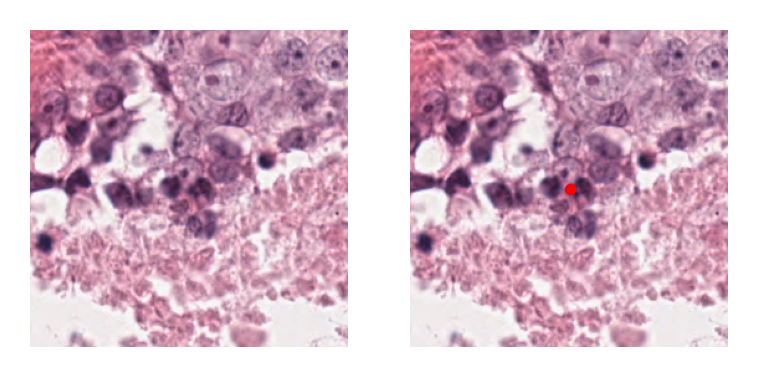

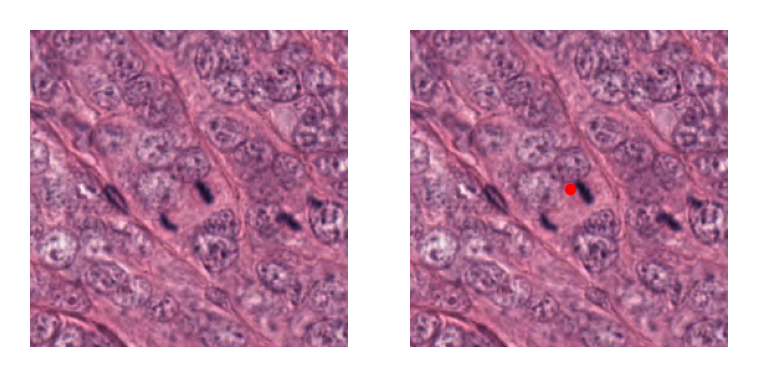

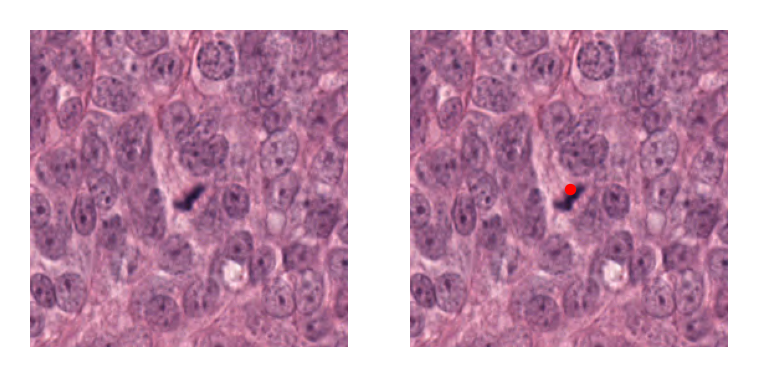

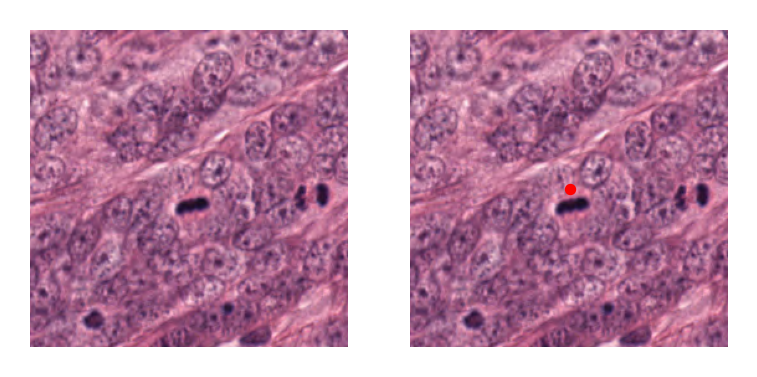

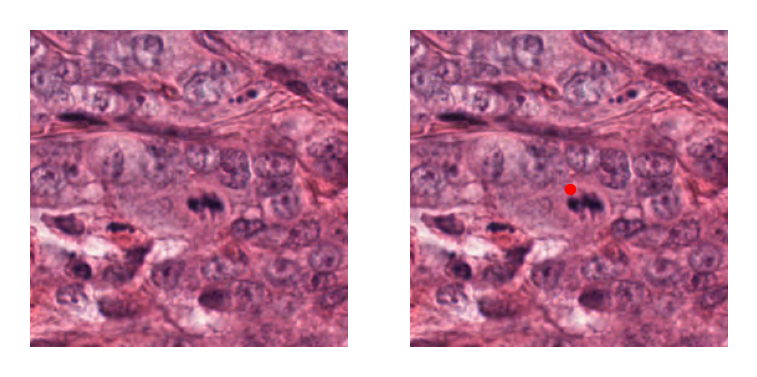

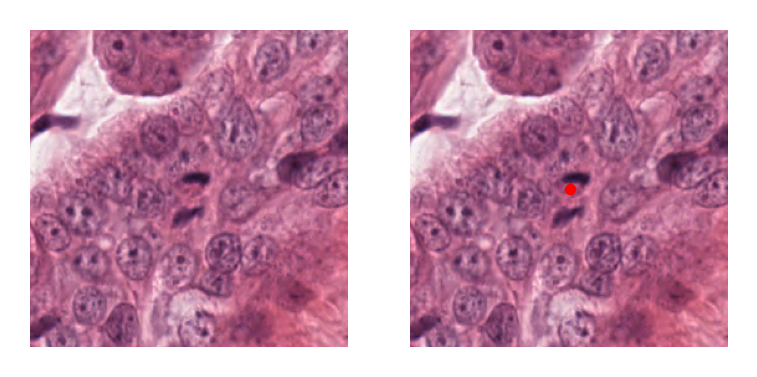

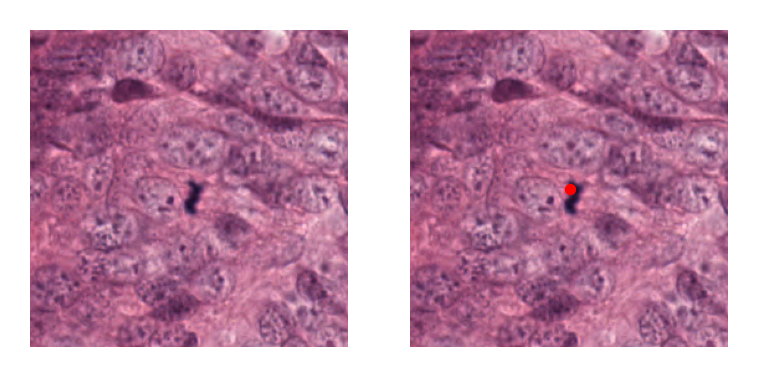

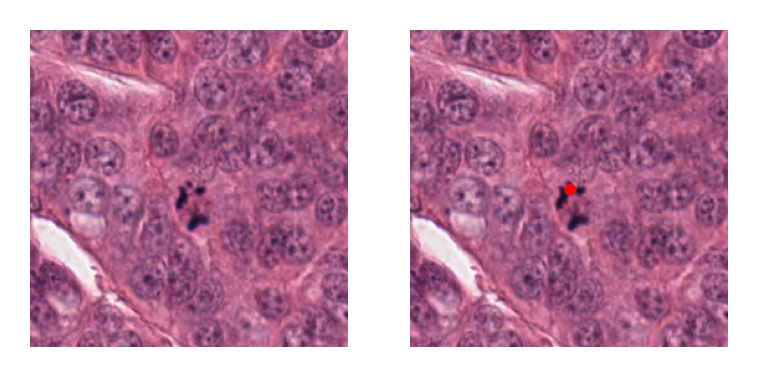

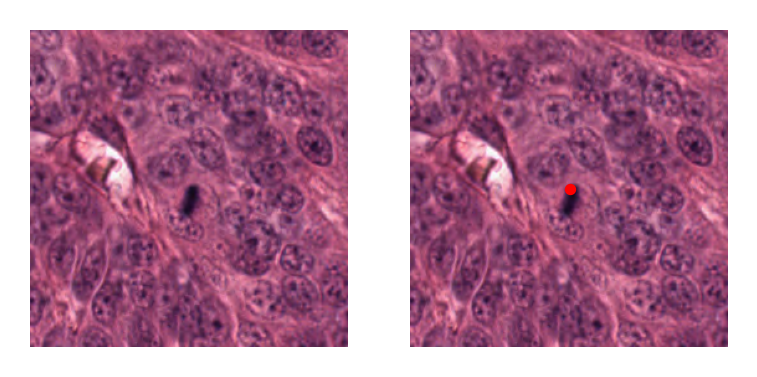

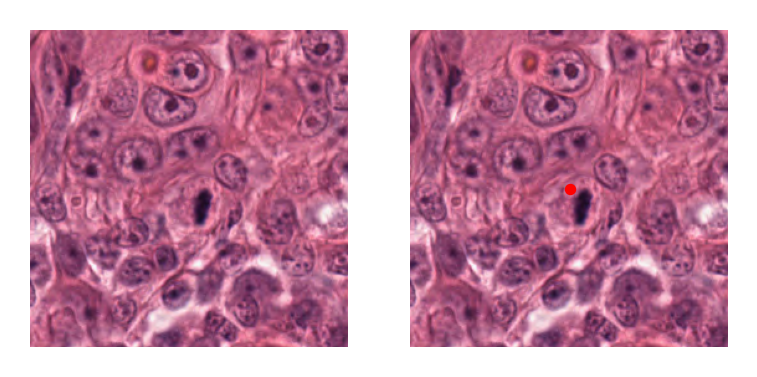

In [20]:
print(wsi_output)

wsi_annotation_store_path = wsi_output[Path(CMC_wsi_path)]

store = SQLiteStore.open(wsi_annotation_store_path)
print(len(store))
max_annotations = min(10, len(store))  # Limit to 10 or 1% of total annotations for display

for ann in list(store.values())[:max_annotations]:
    logger.info(ann)

    x, y = ann.geometry.centroid.coords[0]

    image_path = wsi_reader.read_rect(
        location=(int(x) - 128, int(y) - 128), size=(256, 256), resolution=0, units='level'
    )

    fig, ax = plt.subplots(figsize=(3, 3), nrows=1, ncols=2)
    ax[0].imshow(image_path)
    ax[0].axis("off")
    
    ax[1].imshow(image_path)
    ax[1].scatter(128, 128, s=3, c="red")
    ax[1].axis("off")

    plt.show()

## Lymphocytes and Monocytes Detection in PAS-Stained WSI

In this section, we will demonstrate the use of the pretrained KongNet models for lymphocytes and monocytes detection in PAS-stained kidney biopsies. The model we demonstrate can detect lymphocytes, monocytes, and overall mononuclear leukyocytes in the image and output their coordinates.


Metadata: Objective power inferred from microns-per-pixel (MPP).


Text(0.5, 1.0, 'WSI Thumbnail')

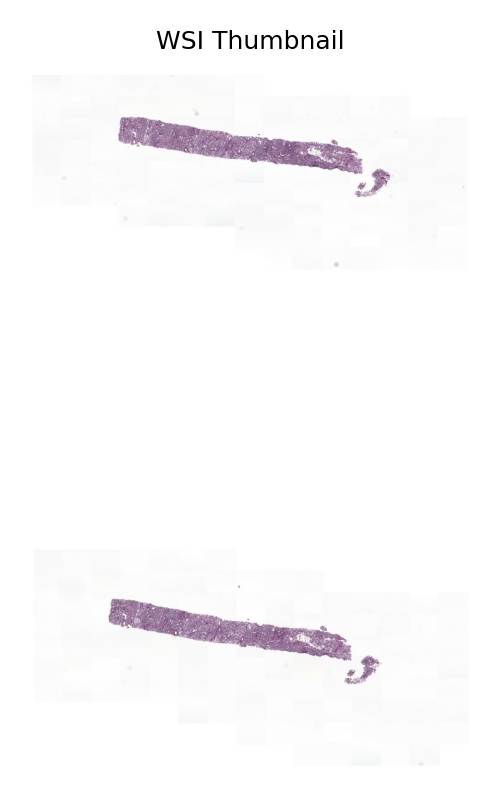

In [23]:
wsi_reader = WSIReader.open(PAS_wsi_path)

logger.info(wsi_reader.info.as_dict())

thumbnail = wsi_reader.slide_thumbnail()
fig, axes = plt.subplots(1, 1, figsize=(3, 3))
axes.imshow(thumbnail)
axes.axis("off")
axes.set_title("WSI Thumbnail")

In [24]:
detector = NucleusDetector(model="KongNet_MONKEY_1")

wsi_output = detector.run(
    images=[Path(PAS_wsi_path)],
    masks=None,
    patch_mode=False,
    device=device,
    save_dir=tmp_dir / "wsi_results/",
    overwrite=True,
    output_type="annotationstore",
    auto_get_mask=True,
    memory_threshold=25,
    num_workers=0,
    batch_size=4,
)

GPU is not compatible with torch.compile. Compatible GPUs include NVIDIA V100, A100, and H100. Speedup numbers may be lower than expected.


Processing WSIs:   0%|          | 0/1 [00:00<?, ?it/s]

Metadata: Objective power inferred from microns-per-pixel (MPP).


Inferring patches:   0%|          | 0/652 [00:00<?, ?it/s]

Current Memory usage: 46.3 %  exceeds specified threshold: 25. Saving intermediate results to disk.
Current Memory usage: 46.3 %  exceeds specified threshold: 25. Saving intermediate results to disk.
Current Memory usage: 46.3 %  exceeds specified threshold: 25. Saving intermediate results to disk.
Current Memory usage: 46.3 %  exceeds specified threshold: 25. Saving intermediate results to disk.
Current Memory usage: 46.3 %  exceeds specified threshold: 25. Saving intermediate results to disk.
Current Memory usage: 46.3 %  exceeds specified threshold: 25. Saving intermediate results to disk.
Current Memory usage: 46.3 %  exceeds specified threshold: 25. Saving intermediate results to disk.
Current Memory usage: 46.3 %  exceeds specified threshold: 25. Saving intermediate results to disk.
Current Memory usage: 46.3 %  exceeds specified threshold: 25. Saving intermediate results to disk.
Current Memory usage: 46.3 %  exceeds specified threshold: 25. Saving intermediate results to disk.


: 

### Visualization using TIAViz

TIAToolbox provides a flexible visualization tool for viewing slides and overlaying associated model outputs or annotations. It is a browser-based UI built using TIAToolbox and Bokeh. Below we show how to use this tool for our prediction example.

Note: To visualize the images and output on TIAViz, we recommend running the following code locally on your machine instead of Google Colab.

In [ ]:
%%bash
tiatoolbox visualize --slides ./tmp/sample_wsis/ --overlays ./tmp/wsi_results/